# Quality control

A cell can be bad, the image it came from can be bad, or the whole well can be. This page flags each level on the
13,578 cells of {func}`~mantispy.ds.jump_cells`: 24 wells of the JUMP plate `BR00121438`, four fields of view
each, as CellProfiler measured them {cite:p}`Chandrasekaran_2023`. The first call downloads about 1.5 GB.

The QC functions only write flags. The `filter_` functions drop what was flagged, and you choose which to call.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mantispy as mt

cells = mt.ds.jump_cells()
cells

AnnData object with n_obs × n_vars = 13578 × 5839
    obs: 'Metadata_ImageNumber', 'Metadata_ObjectNumber', 'Metadata_AbsPositionZ', 'Metadata_AbsTime', 'Metadata_BinningX', 'Metadata_BinningY', 'Metadata_ChannelID', 'Metadata_ChannelName', 'Metadata_Col', 'Metadata_ExposureTime', 'Metadata_FieldID', 'Metadata_ImageResolutionX', 'Metadata_ImageResolutionY', 'Metadata_ImageSizeX', 'Metadata_ImageSizeY', 'Metadata_MainEmissionWavelength', 'Metadata_MainExcitationWavelength', 'Metadata_MaxIntensity', 'Metadata_ObjectiveMagnification', 'Metadata_ObjectiveNA', 'Metadata_PlaneID', 'Metadata_Plate', 'Metadata_PositionX', 'Metadata_PositionY', 'Metadata_PositionZ', 'Metadata_Row', 'Metadata_Site', 'Metadata_Well', 'Metadata_Center_X', 'Metadata_Center_Y', 'Metadata_Source', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'selected

## Images

`MeasureImageQuality` gives focus, saturation and dynamic-range statistics per field of view, 96 fields here.
`image_qc` flags fields that are outliers within their own plate. Pooling plates would flag every field on a
uniformly dimmer plate and miss a blurred field on a bright one.

In [2]:
mt.pp.image_qc(cells, method="mad")
images = cells.uns["mantispy"]["image_qc"]
print(f"{int((~images['qc_image_pass']).sum())} of {len(images)} fields flagged")
images.sort_values("qc_image_score", ascending=False)[
    ["Metadata_Well", "Metadata_Site", "qc_image_score", "qc_image_pass"]
].head()

9 of 96 fields flagged


,Metadata_Well,Metadata_Site,qc_image_score,qc_image_pass
ImageNumber,,,,
20,B09,4,19.483637,False
17,B09,1,19.113390,False
61,J09,1,14.748206,False
18,B09,2,13.430829,False
14,B04,2,9.030103,False


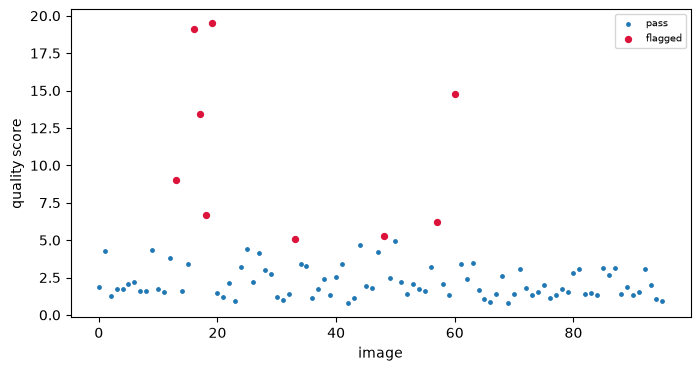

In [3]:
mt.pl.image_qc(cells)
plt.show()

In [4]:
print(
    "compound in B09:",
    cells.obs.loc[cells.obs["Metadata_Well"] == "B09", "Metadata_Perturbation"].iloc[0],
    "| median Mito focus score over the plate:",
    round(float(images["ImageQuality_FocusScore_OrigMito"].median()), 4),
)
images.loc[images["Metadata_Well"] == "B09", ["Metadata_Site", "ImageQuality_FocusScore_OrigMito", "qc_image_pass"]]

compound in B09: JCP2022_098688 | median Mito focus score over the plate: 0.0044


,Metadata_Site,ImageQuality_FocusScore_OrigMito,qc_image_pass
ImageNumber,,,
17,1,0.043975,False
18,2,0.032221,False
19,3,0.018285,False
20,4,0.044741,False


Nine of the 96 fields are flagged, and four of them are the fields of one well, B09, whose Mito focus score is four
to ten times the plate's median. B09 received a compound, not DMSO. A focus score measures fine texture, so a
compound that changes the texture of the Mito stain moves it the way a blurred image would. Look at a flagged field
before dropping it: filtering these four removes the whole of one treated well.

In [5]:
knn = mt.pp.image_qc(cells, method="knn", copy=True).uns["mantispy"]["image_qc"]
{
    "flagged by mad": sorted(images.index[~images["qc_image_pass"]]),
    "flagged by knn": sorted(knn.index[~knn["qc_image_pass"]]),
}

{'flagged by mad': [14, 17, 18, 19, 20, 34, 49, 58, 61],
 'flagged by knn': [21, 46, 49, 51, 61]}

The two methods agree on two fields. `mad` flags a field where any single metric is extreme, `knn` one whose
combination of metrics is unusual, and on real images they mostly flag different ones. `filter_images` drops the
fields `mad` flagged, and their cells with them.

In [6]:
mt.pp.filter_images(cells)
cells.shape

(12320, 5839)

## Cells

`calculate_qc_metrics` writes per-cell and per-feature statistics. The most important one is `qc_nan_fraction`.
Some missing values are normal in CellProfiler output, because some measurements are undefined for some
objects, so `qc_pass` thresholds the fraction of missing features instead of
requiring none.

In [7]:
mt.pp.calculate_qc_metrics(cells)
{
    "cells with some missing data": round(float((cells.obs["qc_n_nan_features"] > 0).mean()), 3),
    "cells passing QC": round(float(cells.obs["qc_pass"].mean()), 3),
}

{'cells with some missing data': 0.001, 'cells passing QC': 0.995}

In [8]:
mt.pp.filter_cells(cells, min_cells_per_well=20)
mt.pp.filter_features(cells, min_variance=1e-8)
cells.shape

(12260, 5685)

Dropping the flagged fields took the plate from 13,578 cells to 12,320. Real CellProfiler output has few missing
values here: one cell in a thousand has any. `filter_cells` drops the 60 cells that failed, and `filter_features`
the 154 features that did not vary.

## Wells

`well_qc` summarizes each well: how many cells passed, how much data is missing and, for control wells, how
variable the controls are, which is `control_cv` and blank on treated wells.

In [9]:
mt.pp.well_qc(cells, min_cells=100)
cells.uns["mantispy"]["well_qc"].sort_values("n_cells").head()

,Metadata_Plate,Metadata_Well,n_cells,nan_fraction,control_cv,qc_well_pass
11,BR00121438,H19,252,0.000000,NaN,True
14,BR00121438,J09,331,0.000004,NaN,True
20,BR00121438,O05,377,0.000000,NaN,True
2,BR00121438,B01,397,0.000006,NaN,True
3,BR00121438,B04,407,0.000000,NaN,True


The thinnest remaining well holds 252 cells, so every well passes a floor of 100. B09 is no longer among
them: `filter_images` removed all four of its fields.

## Outlying cells

Outlier detection cleans the rows. A segmentation
failure, a clump of debris or a dying cell gives an extreme profile that says nothing about
the perturbation.

This section starts again from the cells as they were loaded.

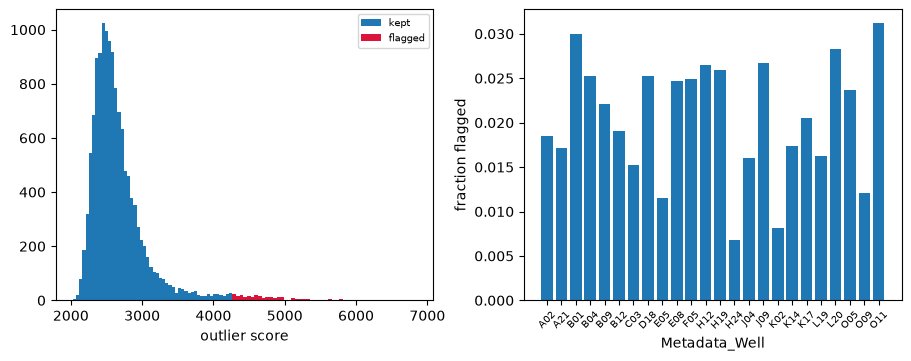

In [10]:
jump = mt.ds.jump_cells()
mt.pp.outliers(jump, contamination=0.02)
mt.pl.outliers(jump, groupby="Metadata_Well")
plt.show()

{func}`~mantispy.pp.outliers` writes a flag and a score and removes nothing. The histogram shows
the flagged tail of the score, and the bars the fraction flagged in each well. It scores only
the features `var["selected"]` marks, so a block of near-duplicate features cannot outvote the
rest.

The default method, `ecod` {cite:p}`Li_2023`, needs no tuning. A cell's score is the sum over
features of how far into a tail it sits, measured by rank, so the scale of a feature does not
matter. `isolation_forest` catches cells that are unusual in their combination of features,
and `mad` takes the largest robust z-score of any single feature, so `score_cutoff=5` applies
the usual five-robust-standard-deviations rule instead of a fixed fraction.

### What gets flagged

Three measurements that are easy to picture, as percentiles within the plate:

In [11]:
features = ["Cells_AreaShape_Area", "Nuclei_AreaShape_Area", "Nuclei_Intensity_MeanIntensity_DNA"]
percentiles = mt.get.to_dataframe(jump, metadata=False, features=features).rank(pct=True)
percentiles.groupby(jump.obs["qc_outlier"]).median().round(2)

,Cells_AreaShape_Area,Nuclei_AreaShape_Area,Nuclei_Intensity_MeanIntensity_DNA
qc_outlier,,,
False,0.51,0.51,0.49
True,0.06,0.07,0.97


Flagged cells are small, with small nuclei and bright DNA. Rounded cells look like that:
cells in division, dying cells and fragments. Two fields of well O09 were imaged as well, and
{func}`~mantispy.ds.jump_plate` downloads them (44 MB), so the flagged cells there can be set
beside cells that were kept. DNA is red, AGP green and Mito blue, and the white line is
CellProfiler's outline of the cell.

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/ETcli4Pw/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/tim.treis/Documents/GitHub/mantispy-wt-reorg/src/mantispy/io/_gallery.py:355: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  [_prefix(pd.read_csv(file), "Cells").assign(Metadata_Key=file.parent.name) for file in files],
/Users/tim.treis/Documents/GitHub/mantispy-wt-reorg/src/mantispy/io/_gallery.py:355: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  [_prefix(pd.read_csv(file), "Cells").assign(Metadata_Key=file.parent.name) for file in files],


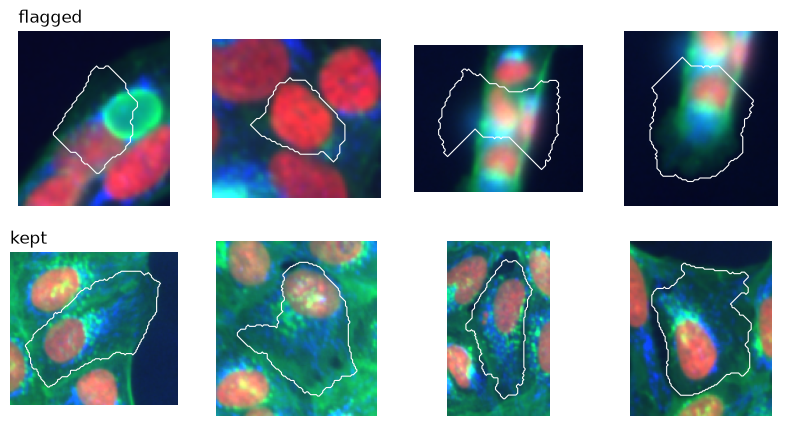

In [12]:
from spatialdata import get_pyramid_levels

plate = mt.ds.jump_plate()
imaged = jump.obs[(jump.obs["Metadata_Well"] == "O09") & jump.obs["Metadata_Site"].isin([1, 2])]
examples = {
    "flagged": imaged[imaged["qc_outlier"]].head(4),
    "kept": imaged[~imaged["qc_outlier"]].sample(4, random_state=0),
}

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for row, (label, cells_shown) in zip(axes, examples.items(), strict=True):
    row[0].set_title(label, loc="left")
    for ax, (_, cell) in zip(row, cells_shown.iterrows(), strict=False):
        field = f"BR00121438_O09_s{cell['Metadata_Site']}"
        mask = np.asarray(plate[f"{field}_cells"]) == cell["Metadata_ObjectNumber"]
        ys, xs = np.nonzero(mask)
        window = np.s_[max(ys.min() - 15, 0) : ys.max() + 15, max(xs.min() - 15, 0) : xs.max() + 15]
        image = get_pyramid_levels(plate[f"{field}_image"], n=0)
        rgb = np.stack([np.asarray(image.sel(c=c))[window] for c in ("DNA", "AGP", "Mito")], axis=-1).astype(float)
        ax.imshow((rgb / np.percentile(rgb, 99.5, axis=(0, 1))).clip(0, 1))
        ax.contour(mask[window], levels=[0.5], colors="white", linewidths=0.8)
for ax in axes.flat:
    ax.set_axis_off()
plt.show()

The kept cells are flat and spread out. The flagged ones are rounded, out of focus and badly
outlined: the first outline covers the space beside a round cell rather than the cell, the
second holds little but a nucleus, and the last two cut across a column of rounded cells.
Their profiles describe the segmentation more than the cell.

### The methods disagree

In [13]:
flags = {"ecod": jump.obs["qc_outlier"].to_numpy()}
for name, kwargs in {
    "ecod, paper": {"ecod_aggregation": "paper"},
    "isolation_forest": {"method": "isolation_forest"},
    "mad": {"method": "mad"},
}.items():
    mt.pp.outliers(jump, contamination=0.02, key_added="qc_compare", **kwargs)
    flags[name] = jump.obs["qc_compare"].to_numpy()

pd.DataFrame({a: {b: (flags[a] & flags[b]).sum() / (flags[a] | flags[b]).sum() for b in flags} for a in flags}).round(2)

,ecod,"ecod, paper",isolation_forest,mad
ecod,1.00,0.79,0.81,0.21
"ecod, paper",0.79,1.00,0.77,0.21
isolation_forest,0.81,0.77,1.00,0.24
mad,0.21,0.21,0.24,1.00


The table is the Jaccard index between flagged sets. `ecod` and `isolation_forest` flag
largely the same cells. `mad` flags mostly others, because one extreme feature is enough for it.
`ecod_aggregation="paper"` scores as Algorithm 1 of {cite:t}`Li_2023` does rather than as pyod
does, and on these cells it shares most of its flags with the default.

### Is it removing a phenotype?

In [14]:
per_well = jump.obs.groupby("Metadata_Well", observed=True).agg(
    control=("Metadata_Control", "first"), flagged=("qc_outlier", "mean")
)
per_well.groupby("control")["flagged"].agg(["count", "min", "median", "max"]).round(3)

,count,min,median,max
control,,,,
False,16,0.007,0.021,0.030
True,8,0.011,0.022,0.031


Control and compound wells lose similar fractions, between about 0.7 % and 3 % of a well, so here the
flags do not concentrate on one compound's wells. On a plate with a
strong phenotype they may not: a compound that stops cells in division fills its wells with
exactly the rounded cells flagged above. Look at this table before dropping anything. If one
perturbation's wells stand out, pass `by="Metadata_Well"` so each well is compared only with
itself, or keep the cells.

Next: [Normalize, select, aggregate](normalize_and_select.ipynb).